In [16]:
from pathlib import Path
import pandas as pd
import seaborn as sns
from tqdm.notebook import tqdm
from concurrent.futures import ThreadPoolExecutor, as_completed
from subprocess import run, PIPE
import os
import torch
import matplotlib.pyplot as plt
import numpy as np

### Check len

In [36]:
DATA_PATH = Path("/mnt/data/kusnierz/audio-data/SingFake/downloads")

In [37]:
files = [p for p in DATA_PATH.rglob("*") if p.is_file() and p.suffix.lower() == ".flac"]

def ffprobe_duration(path: Path):
    cmd = [
        "ffprobe", "-v", "error",
        "-show_entries", "format=duration",
        "-of", "default=noprint_wrappers=1:nokey=1",
        str(path)
    ]
    proc = run(cmd, stdout=PIPE, stderr=PIPE, text=True)
    if proc.returncode != 0 or not proc.stdout.strip():
        return {"error": True, "filepath": str(path), "error_msg": proc.stderr.strip() or "no-duration"}
    try:
        dur = float(proc.stdout.strip())
        return {"filename": path.stem, "filepath": str(path), "duration": int(dur)}
    except Exception as e:
        return {"error": True, "filepath": str(path), "error_msg": repr(e)}

results = []
failed = []
max_workers = min(32, max(4, (os.cpu_count() or 4) * 2))
with ThreadPoolExecutor(max_workers=max_workers) as ex:
    futures = {ex.submit(ffprobe_duration, p): p for p in files}
    for fut in tqdm(as_completed(futures), total=len(futures)):
        res = fut.result()
        if res.get("error"):
            failed.append((res["filepath"], res["error_msg"]))
        else:
            results.append(res)

df = pd.DataFrame(results)
failed_df = pd.DataFrame(failed, columns=["filepath", "error"])
print("success:", len(df), "failed:", len(failed_df))

  0%|          | 0/1218 [00:00<?, ?it/s]

success: 1218 failed: 0


In [38]:
df.describe()

,duration
count,1218.000000
mean,244.570608
std,63.279262
min,16.000000
25%,216.250000
50%,250.000000
75%,280.000000
max,503.000000


In [47]:
filtered_df = df[df['duration'] < 1000]

In [48]:
filtered_df

,filename,filepath,duration
0,T01_Stefanie_Sun_我要的幸福-孙燕姿_bonafide,/mnt/data/kusnierz/audio-data/SingFake/downloa...,267
1,Training_Stefanie_Sun_极美-孙燕姿_bonafide,/mnt/data/kusnierz/audio-data/SingFake/downloa...,272
2,Training_Mayday_010._明年今日_bonafide,/mnt/data/kusnierz/audio-data/SingFake/downloa...,206
3,Training_Kenshi_Yonezu_ピースサイン_bonafide,/mnt/data/kusnierz/audio-data/SingFake/downloa...,235
4,T02_Eason_Chan_【4K24FPS】陈奕迅《任我行》纵然是洒脱人生境界，但人不能...,/mnt/data/kusnierz/audio-data/SingFake/downloa...,292
...,...,...,...
1213,Training_Hebe_Tien_[AI_田馥甄]_听见下雨的声音_cover.周杰伦_...,/mnt/data/kusnierz/audio-data/SingFake/downloa...,130
1214,Training_Mayday_离开地球表面_bonafide,/mnt/data/kusnierz/audio-data/SingFake/downloa...,285
1215,T02_Eason_Chan_018._你的背包_bonafide,/mnt/data/kusnierz/audio-data/SingFake/downloa...,237
1216,Validation_G.E.M._【AI_邓紫棋】-《爱在西元前》我给你的爱写在西元前~高...,/mnt/data/kusnierz/audio-data/SingFake/downloa...,223


In [49]:
filtered_df.describe()

,duration
count,1218.000000
mean,244.570608
std,63.279262
min,16.000000
25%,216.250000
50%,250.000000
75%,280.000000
max,503.000000


<Axes: xlabel='duration', ylabel='Count'>

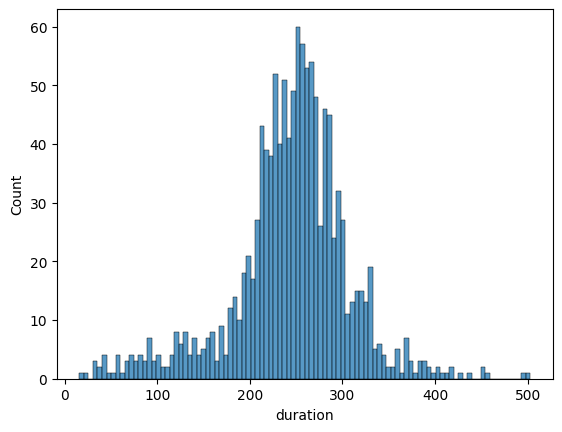

In [50]:
sns.histplot(filtered_df, x='duration', bins=100)

In [51]:
tmp_path = df.iloc[10]['filepath']

In [52]:
import torchaudio

In [ ]:
wav, sr = torchaudio.load(tmp_path)

resampler = torchaudio.transforms.Resample(orig_freq=sr, new_freq=16000)
wav = resampler(wav)

spectrogram_layer = torchaudio.transforms.MelSpectrogram(sample_rate=16000, n_fft=2048, n_mels=128, hop_length=160)
spectrogram = spectrogram_layer(wav)

In [77]:
spectrogram.shape

torch.Size([2, 128, 26702])

In [78]:
part = spectrogram[0, :, :4096]

In [79]:
S_db = torchaudio.transforms.AmplitudeToDB()(part)

In [80]:
import matplotlib.pyplot as plt

<Axes: >

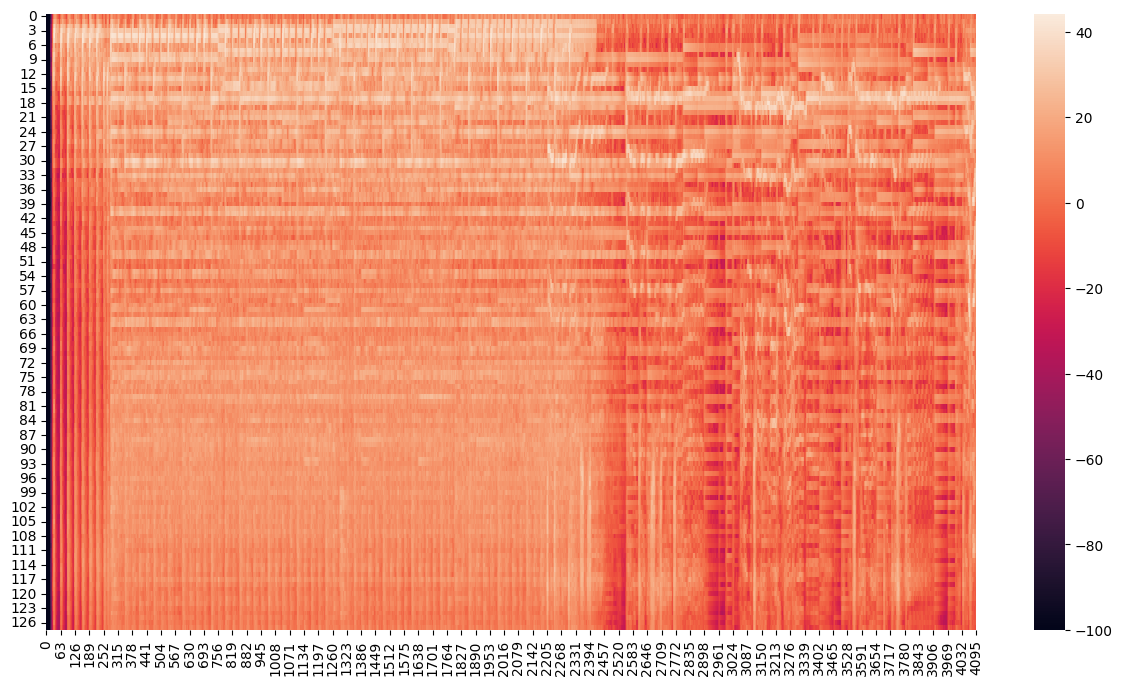

In [81]:
plt.figure(figsize=(15,8))
sns.heatmap(S_db)

### Check data after resample + spectrograms + normalization

In [2]:
import rootutils
ROOT = rootutils.setup_root(".", indicator=".project-root", pythonpath=True)

In [3]:
from src.data.singfake_dataloader import SingFakeDataModule

In [4]:
spectrogram_path = Path("/mnt/data/kusnierz/audio-data/SingFake/spectrograms")
specs_list = list(spectrogram_path.rglob("*.pt"))

In [5]:
spec = torch.load(specs_list[20])

In [6]:
spec.shape

torch.Size([6784, 80])

In [7]:
params = {"sample_rate": 16000,
"n_fft": 1024,
"n_mels": 80,
"hop_length": 512,
"max_len": 8000000}

In [8]:
dataloader = SingFakeDataModule(
    "/mnt/data/kusnierz/audio-data/SingFake/spectrograms",
    16,
    8,
    **params
    )

In [9]:
dataloader.setup(stage='fit')

Unknown label in file: Validation_The_Landlord's_Cat_【AI_房东的猫】-《形容》_糟了，怎么能那么好听！COVER沈以诚_unknown, last part: unknown


In [10]:
dataset = dataloader.training_dataset

In [11]:
obj, label = dataset.__getitem__(20)

In [12]:
obj.shape

torch.Size([9331, 80])

In [21]:
obj.size(0)

9331

<Axes: >

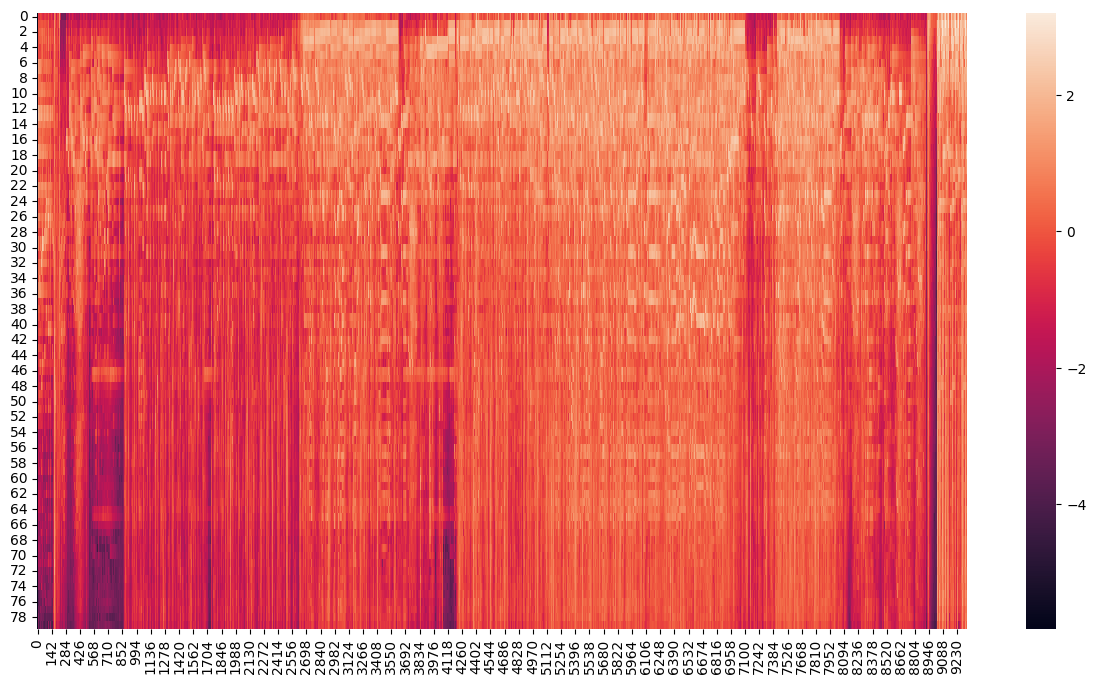

In [13]:
plt.figure(figsize=(15,8))
sns.heatmap(obj.transpose(0,1))

In [14]:
import random

LABEL_MAP = {"bonafide": 1, "spoof": 0}

def infer_label_from_stem(stem: str):
    parts = stem.split("_")
    if len(parts) == 0:
        return None
    last = parts[-1].lower()
    return last if last in LABEL_MAP else None

def pick_files(data_dir: Path, mode: str, n_bona: int, n_spoof: int, seed: int = 42):
    random.seed(seed)
    files = [p for p in data_dir.rglob("*") if p.is_file()]
    if mode == "spec":
        files = [p for p in files if p.suffix.lower() == ".pt"]
    else:
        files = [p for p in files if p.suffix.lower() in {".flac", ".wav", ".mp3", ".m4a", ".ogg"}]

    bona = []
    spoof = []
    for p in files:
        lab = infer_label_from_stem(p.stem)
        if lab == "bonafide":
            bona.append(p)
        elif lab == "spoof":
            spoof.append(p)

    if len(bona) < n_bona or len(spoof) < n_spoof:
        raise ValueError(f"Not enough samples found (bona: {len(bona)}, spoof: {len(spoof)})")

    return random.sample(bona, n_bona), random.sample(spoof, n_spoof)

def load_spec_for_plot(path: Path):
    t = torch.load(path, map_location="cpu", weights_only=False)
    if not torch.is_tensor(t):
        raise RuntimeError(f"{path} did not contain a tensor")
    t = t.squeeze()
    if t.ndim != 2:
        raise RuntimeError(f"Unsupported tensor shape {t.shape} in {path}")
    # If saved as [Time, Feat] -> transpose to [Freq, Time] for plotting.
    if t.shape[0] > t.shape[1]:
        arr = t.T.numpy()
    else:
        arr = t.numpy()
    return arr  # shape: [freq, time] for imshow

def load_audio(path: Path, target_sr: int = 16000):
    wav, sr = torchaudio.load(path)
    if wav.size(0) > 1:
        wav = wav.mean(dim=0, keepdim=True)
    if sr != target_sr:
        resampler = torchaudio.transforms.Resample(orig_freq=sr, new_freq=target_sr)
        wav = resampler(wav)
    return wav, target_sr

def concat_audio(paths, out_path: Path, target_sr: int = 16000):
    parts = []
    for p in paths:
        wav, sr = load_audio(p, target_sr=target_sr)
        parts.append(wav)
    combined = torch.cat(parts, dim=1)
    torchaudio.save(str(out_path), combined, target_sr)
    return out_path

In [19]:
DATA_DIR = Path("/mnt/data/kusnierz/audio-data/SingFake/spectrograms")  # change if needed
MODE = "spec"   # "spec" or "audio"
N_BONA = 5
N_SPOOF = 5
SEED = 123

bona_files, spoof_files = pick_files(DATA_DIR, MODE, N_BONA, N_SPOOF, seed=SEED)
print("Bona samples:")
for p in bona_files: print(" ", p.name)
print("Spoof samples:")
for p in spoof_files: print(" ", p.name)

Bona samples:
  T02_Miriam_Yeung_楊千嬅_Miriam_Yeung_-《小城大事》Official_MV_bonafide.pt
  Validation_The_Landlord's_Cat_【房东的猫】《躺在凌晨五点半的海岸》MV_bonafide.pt
  T02_Angela_Chang_張韶涵_Angela_Zhang_-_親愛的那不是愛情_(官方版MV)_bonafide.pt
  Training_Mao_Buyi_毛不易_-_别再闹了_-_《来电狂响》电影暖冬主题曲_bonafide.pt
  Training_Hebe_Tien_【4K珍藏】田馥甄《小幸运》我的少女时代版！_bonafide.pt
Spoof samples:
  Training_Mayday_AI翻唱-五月天阿信_嘉宾_spoof.pt
  Training_Mao_Buyi_【AI翻唱_毛不易】当毛不易翻唱[杀死那个石家庄人]_spoof.pt
  Training_Mao_Buyi_【AI翻唱_毛不易】当毛不易翻唱[阳光开朗大男孩]_spoof.pt
  Validation_G.E.M._【AI翻唱_不是“邓紫棋”】_《美人魚》cover_林俊傑_spoof.pt
  Training_Stefanie_Sun_【AI_孙燕姿】《我不配》这感觉已经不对，我努力在挽回_spoof.pt


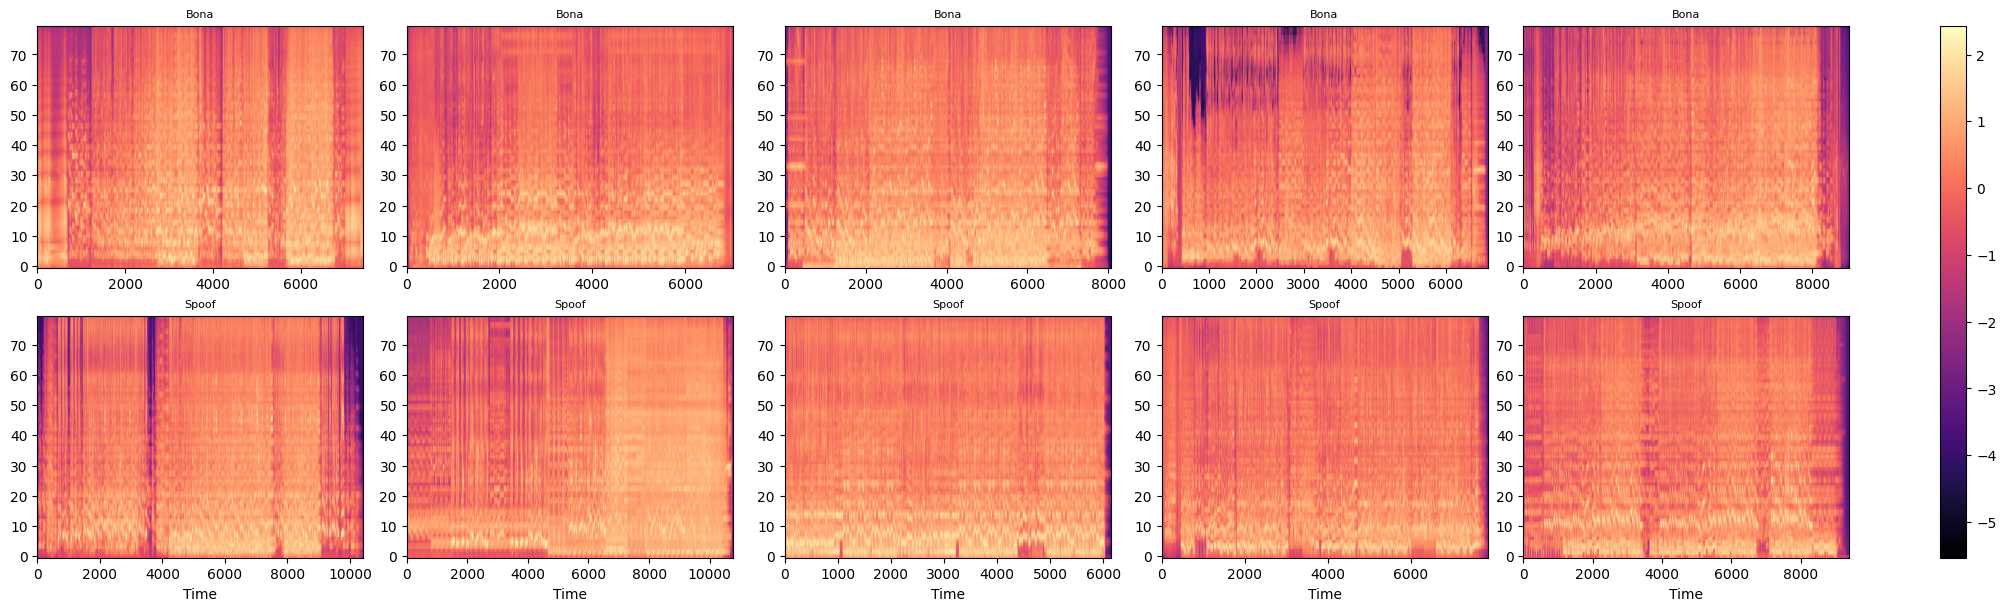

In [20]:
def plot_bona_spoof(bona_paths, spoof_paths, figsize_per_col=(4,3), cmap="magma", vmin=None, vmax=None):
    cols = max(len(bona_paths), len(spoof_paths))
    fig, axes = plt.subplots(2, cols, figsize=(figsize_per_col[0]*cols, figsize_per_col[1]*2), constrained_layout=True)
    if cols == 1:
        axes = np.expand_dims(axes, axis=1)
    for c in range(cols):
        # Bona
        ax_b = axes[0, c]
        if c < len(bona_paths):
            arr = load_spec_for_plot(bona_paths[c])
            im = ax_b.imshow(arr, aspect="auto", origin="lower", cmap=cmap, vmin=vmin, vmax=vmax)
            ax_b.set_title("Bona", fontsize=8)
        else:
            ax_b.axis("off")
        # Spoof
        ax_s = axes[1, c]
        if c < len(spoof_paths):
            arr = load_spec_for_plot(spoof_paths[c])
            ax_s.imshow(arr, aspect="auto", origin="lower", cmap=cmap, vmin=vmin, vmax=vmax)
            ax_s.set_title("Spoof", fontsize=8)
        else:
            ax_s.axis("off")
        ax_s.set_xlabel("Time")
    # colorbar using last image
    fig.colorbar(im, ax=axes.ravel().tolist(), orientation="vertical", fraction=0.02)
    plt.show()

# Call plotting
plot_bona_spoof(bona_files, spoof_files)

In [ ]:
if MODE == "audio":
    out = concat_audio(bona_files + spoof_files, Path("combined_bona_spoof.wav"))
    print("Saved combined audio to", out)
else:
    print("Skipping audio concat (MODE != 'audio').")

Skipping audio concat (MODE != 'audio').
